In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("customer_data.csv")

In [3]:
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


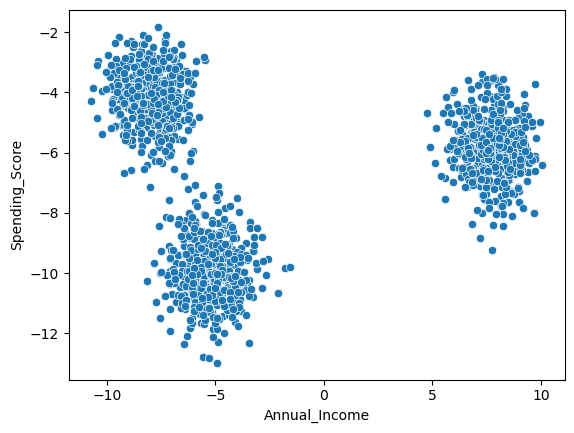

In [5]:
sns.scatterplot(x=df['Annual_Income'],y=df['Spending_Score'])
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test = train_test_split(df, test_size=0.2, random_state=15)

In [8]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.cluster import KMeans

In [10]:
import warnings 
warnings.filterwarnings("ignore")

for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)

In [ ]:
kmeans.labels_ 

array([1, 8, 6, ..., 2, 7, 5])

In [12]:
kmeans.inertia_ #wcss

4.096388488426612

In [13]:
#elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[196.92068784710153,
 68.44836482219307,
 11.697030239519934,
 9.903673351111902,
 7.809003948289901,
 7.223688344914099,
 5.505384081817161,
 5.1790858217131985,
 4.406110695524605,
 4.155265082727398]

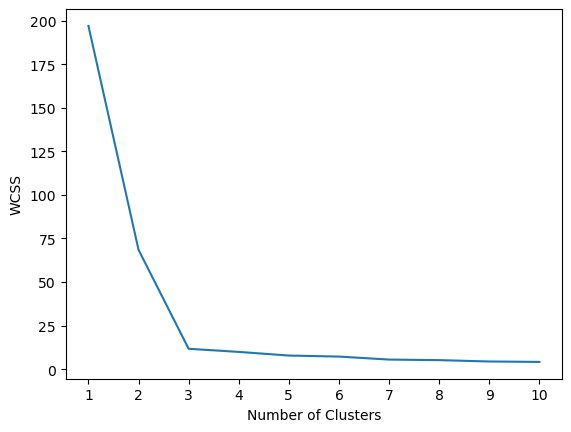

In [15]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(X_train_scaled)

KMeans(n_clusters=3)

In [17]:
y_pred = kmeans.predict(X_test_scaled)

In [18]:
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

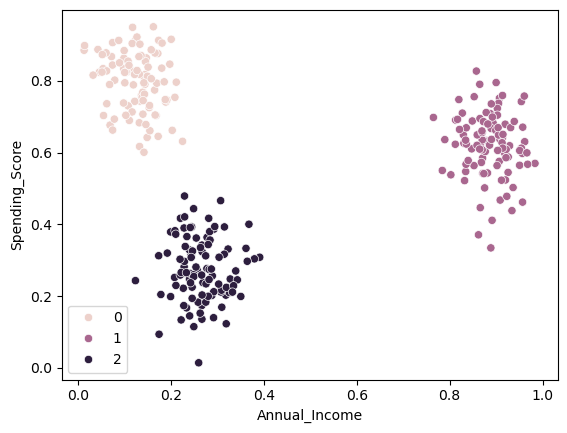

In [19]:
sns.scatterplot(data=X_test_scaled,x="Annual_Income",y="Spending_Score",hue=y_pred)
plt.show()

In [20]:
from kneed import KneeLocator

In [21]:
kl = KneeLocator(range(1,11),wcss, curve="convex",direction="decreasing")
# curve-> convex,concave
# direction->decreasing,increasing

In [22]:
kl.elbow

3

In [46]:
#silhoutte score 

In [48]:
from sklearn.metrics import silhouette_score

In [54]:
silhouette_scores = []
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_scores.append(score)

In [56]:
silhouette_scores

[0.6538372460771634,
 0.7856941696336582,
 0.6400208011797931,
 0.6124018812306176,
 0.5241584042107261,
 0.37245478936778964,
 0.3542138842737253,
 0.3609859441864053,
 0.3345514373995289]

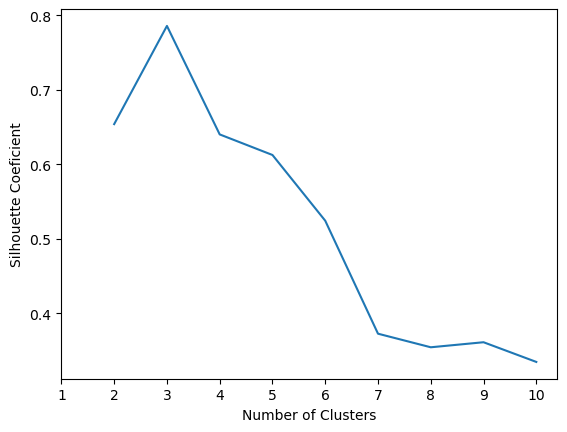

In [58]:
plt.plot(range(2,11),silhouette_scores)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coeficient")
plt.show()